# UNIVERSIDADE FEDERAL DO PIAUÍ – UFPI
## CAMPUS SENADOR HELVÍDIO NUNES DE BARROS – PICOS
**Curso:** Sistemas de Informação | **Período:** 6° | **Ano/Semestre:** 2026.2  
**Disciplina:** Tópicos Especiais em Visão Computacional  
**Professor:** Me. José Denes Lima Araújo  
**Aluno:** João Marcos Sousa Rufino Leal  

---
# 5ª ATIVIDADE - HISTOGRAMA

### Observações e Diretrizes:
* Trabalho individual.
* Códigos implementados na linguagem Python no ambiente Google Colab.
* Trabalho realizado exclusivamente com imagens em **nível de cinza (apenas 1 canal)**.
* **Implementação 100% manual e autoral:** Todas as rotinas de manipulação de histograma (cálculo absoluto, normalização, equalização e especificação) foram implementadas diretamente pelo aluno utilizando operações matemáticas fundamentais, sem o uso de bibliotecas de terceiros prontas (`cv2.calcHist`, `np.histogram`, `cv2.equalizeHist`, `skimage.exposure.match_histograms`, etc.).


---
## Implementação Manual das Rotinas de Histograma

Abaixo estão implementadas as quatro funções fundamentais exigidas na atividade, seguindo rigorosamente as formulações matemáticas apresentadas em aula:

1. `calcular_histograma(img)`: Calcula a frequência absoluta de cada nível de cinza $h(r_k) = n_k$.
2. `normalizar_histograma(hist, total_pixels)`: Calcula a probabilidade de cada nível $p(r_k) = \frac{n_k}{M \times N}$.
3. `equalizar_histograma(img)`: Aplica a equalização discreta $s_k = \text{round}\left( (L - 1) \sum_{j=0}^{k} p_r(r_j) \right)$.
4. `especificar_histograma(img_entrada, img_referencia)`: Mapeia as intensidades da imagem de entrada para aproximar a distribuição da imagem de referência ($HE(r_k) \to z_q$).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
import cv2

# 1. Função manual para cálculo do Histograma Absoluto: h(r_k) = n_k
def calcular_histograma(img):
    """
    Calcula a contagem de ocorrência de cada intensidade de cinza na imagem.
    Retorna um array 1D de tamanho 256 contendo n_k.
    """
    hist = np.zeros(256, dtype=int)
    # Contagem direta percorrendo os pixels da imagem (100% manual)
    for pixel in img.ravel():
        hist[pixel] += 1
    return hist

# 2. Função manual para cálculo do Histograma Normalizado: p(r_k) = n_k / (M * N)
def normalizar_histograma(hist, total_pixels):
    """
    Normaliza o histograma dividindo a contagem n_k pela resolução total M * N.
    Garante que a soma de todas as probabilidades seja igual a 1.0.
    """
    return hist.astype(float) / float(total_pixels)

# 3. Função manual para Equalização de Histograma
def equalizar_histograma(img):
    """
    Aplica a técnica discreta de equalização de histograma baseada na CDF:
    s_k = round((L - 1) * sum_{j=0}^k p_r(r_j))
    """
    M, N = img.shape
    total_pixels = M * N
    hist = calcular_histograma(img)
    pr = normalizar_histograma(hist, total_pixels)
    
    # Cálculo da Função de Distribuição Acumulada (CDF) discreta
    cdf = np.zeros(256, dtype=float)
    soma_acumulada = 0.0
    for k in range(256):
        soma_acumulada += pr[k]
        cdf[k] = soma_acumulada
        
    # Mapeamento discreto: s_k = round((L - 1) * CDF)
    L = 256
    s = np.round((L - 1) * cdf).astype(np.uint8)
    
    # Substituição dos pixels originais pelo valor mapeado
    img_equalizada = s[img]
    
    return img_equalizada, s, pr, cdf

# 4. Função manual para Especificação (Casamento) de Histograma
def especificar_histograma(img_entrada, img_referencia):
    """
    Aplica a especificação de histograma:
    1) Equaliza a imagem de entrada -> s_k = HE(r_k)
    2) Equaliza a imagem de referência -> v_q = HE(z_q)
    3) Para cada s_k, encontra o z_q cujo v_q é o mais próximo de s_k
    4) Mapeia cada pixel r_k da entrada para o z_q correspondente
    """
    # Passo 1: Equalização da imagem de entrada
    _, s_in, pr_in, _ = equalizar_histograma(img_entrada)
    
    # Passo 2: Equalização da imagem de referência
    _, s_ref, pr_ref, _ = equalizar_histograma(img_referencia)
    
    # Passo 3: Tabela de mapeamento s_in[rk] -> zq
    tabela_mapeamento = np.zeros(256, dtype=np.uint8)
    for rk in range(256):
        val_he = s_in[rk]
        # Distância euclidiana absoluta para todos os níveis equalizados da referência
        diferencas = np.abs(s_ref.astype(int) - int(val_he))
        zq_mais_proximo = np.argmin(diferencas)
        tabela_mapeamento[rk] = zq_mais_proximo
        
    # Passo 4: Mapear pixels da imagem de entrada
    img_especificada = tabela_mapeamento[img_entrada]
    
    return img_especificada, tabela_mapeamento, s_in, s_ref

print("Funções manuais de manipulação de histograma carregadas com sucesso!")


Funções manuais de manipulação de histograma carregadas com sucesso!


---
## Questão 1) Transformações de Histograma

Selecione uma imagem (ou mais) e aplique as seguintes transformações:
* **a)** Calcule o histograma utilizando a fórmula correspondente e apresente o gráfico resultante.
* **b)** Normalize o histograma utilizando a fórmula correspondente e apresente o gráfico resultante.
* **c)** Aplique a equalização do histograma utilizando a fórmula. Mostre a imagem original juntamente com o gráfico do seu histograma normalizado. Adicionalmente, mostre a imagem após a equalização e seu histograma correspondente.

---
### Carregamento da Imagem de Teste da Questão 1
Utilizaremos a clássica imagem da superfície lunar (`data.moon()`), que possui tons concentrados na faixa de baixas intensidades (escuros) e baixo contraste, sendo ideal para demonstrar o cálculo do histograma, sua normalização e o poder da equalização.


In [2]:
# Carregando imagem em escala de cinza de 8-bits
img_q1 = data.moon()
M, N = img_q1.shape
total_pixels = M * N

print(f"Imagem carregada: 'data.moon()'")
print(f"Dimensões: {M} x {N} | Total de pixels (M * N): {total_pixels}")
print(f"Faixa dinâmica original: min = {img_q1.min()}, max = {img_q1.max()}")


Imagem carregada: 'data.moon()'
Dimensões: 512 x 512 | Total de pixels (M * N): 262144
Faixa dinâmica original: min = 0, max = 255


---
### 1.a) Cálculo do Histograma Absoluto

**Fórmula:**
$$h(r_k) = n_k$$

Onde $n_k$ representa o número exato de pixels que possuem o nível de cinza $r_k$ ($k \in [0, 255]$).


Soma das frequências do histograma: 262144
Total de pixels na imagem (M * N):   262144
Verificação de consistência: APROVADA (Exata)


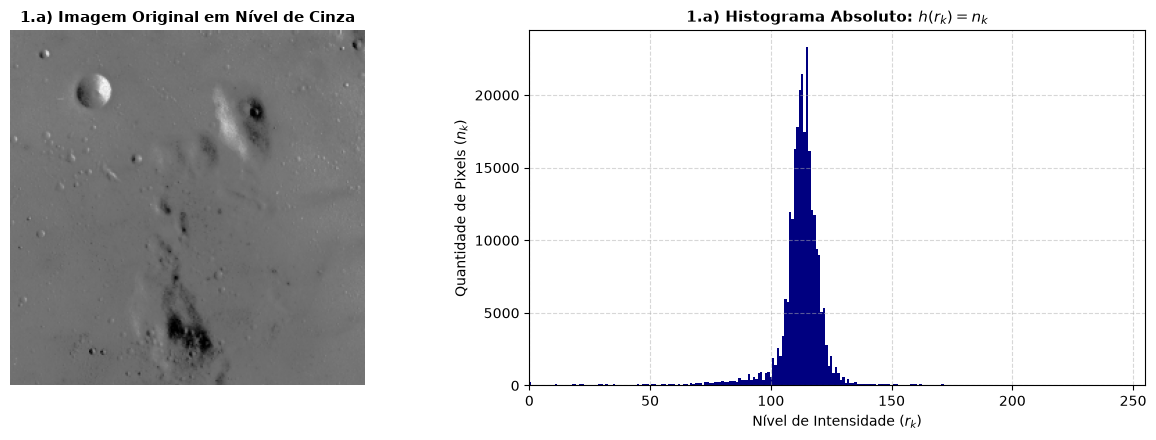

In [3]:
# Cálculo manual do histograma absoluto
hist_abs = calcular_histograma(img_q1)

# Verificação de integridade: a soma das frequências absolutas deve ser igual a M * N
print(f"Soma das frequências do histograma: {np.sum(hist_abs)}")
print(f"Total de pixels na imagem (M * N):   {total_pixels}")
print(f"Verificação de consistência: {'APROVADA (Exata)' if np.sum(hist_abs) == total_pixels else 'ERRO'}")

# Exibição da imagem e do histograma resultante
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].imshow(img_q1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("1.a) Imagem Original em Nível de Cinza", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].bar(range(256), hist_abs, color='navy', width=1.0, edgecolor='none')
axes[1].set_title("1.a) Histograma Absoluto: $h(r_k) = n_k$", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Nível de Intensidade ($r_k$)", fontsize=10)
axes[1].set_ylabel("Quantidade de Pixels ($n_k$)", fontsize=10)
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
### 1.b) Cálculo do Histograma Normalizado

**Fórmula:**
$$p(r_k) = \frac{n_k}{M \times N}$$

Propriedades fundamentais:
* $0 \le p(r_k) \le 1$
* $\sum_{k=0}^{L-1} p(r_k) = 1.0$ (100% dos pixels)


Soma de todas as probabilidades sum(p(r_k)): 1.000000
Verificação de probabilidade: APROVADA (Soma = 1.0)


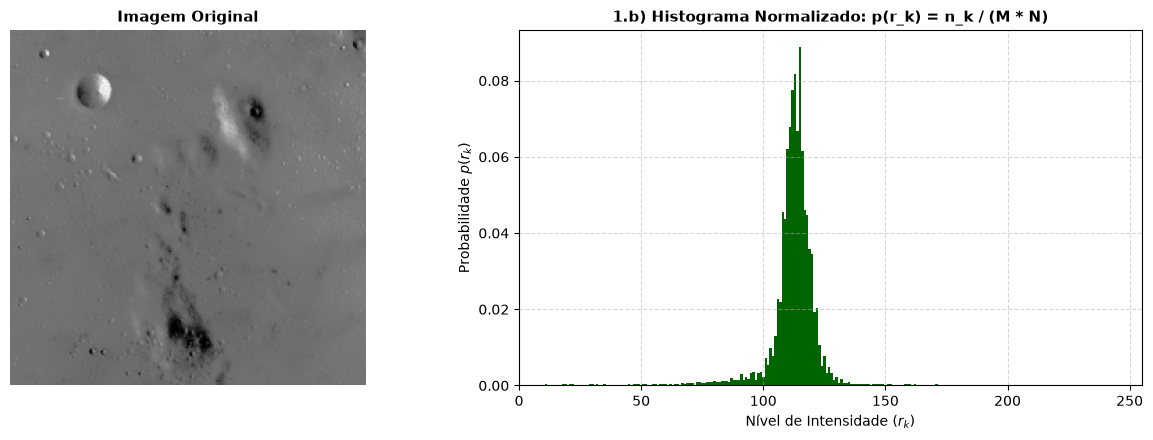

In [4]:
# Cálculo manual do histograma normalizado
hist_norm = normalizar_histograma(hist_abs, total_pixels)

# Verificação formal da soma das probabilidades
soma_prob = np.sum(hist_norm)
print(f"Soma de todas as probabilidades sum(p(r_k)): {soma_prob:.6f}")
print(f"Verificação de probabilidade: {'APROVADA (Soma = 1.0)' if np.isclose(soma_prob, 1.0) else 'ERRO'}")

# Gráfico do histograma normalizado
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].imshow(img_q1, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Imagem Original", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].bar(range(256), hist_norm, color='darkgreen', width=1.0, edgecolor='none')
axes[1].set_title(f"1.b) Histograma Normalizado: p(r_k) = n_k / (M * N)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Nível de Intensidade ($r_k$)", fontsize=10)
axes[1].set_ylabel("Probabilidade $p(r_k)$", fontsize=10)
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
### 1.c) Aplicação da Equalização de Histograma

**Fórmula discreta da transformação:**
$$s_k = T(r_k) = \text{round}\left( (L - 1) \sum_{j=0}^{k} p_r(r_j) \right) = \text{round}\left( \frac{L - 1}{M \times N} \sum_{j=0}^{k} n_j \right)$$

Onde:
* $L = 256$ (para imagens de 8 bits).
* $\sum_{j=0}^{k} p_r(r_j)$ é a Função de Distribuição Acumulada (CDF).
* Cada pixel original $r_k$ é substituído pelo novo valor mapeado $s_k$.

**Apresentação solicitada:**
* Imagem original com o gráfico do seu histograma normalizado.
* Imagem após a equalização com o gráfico do seu histograma normalizado correspondente.


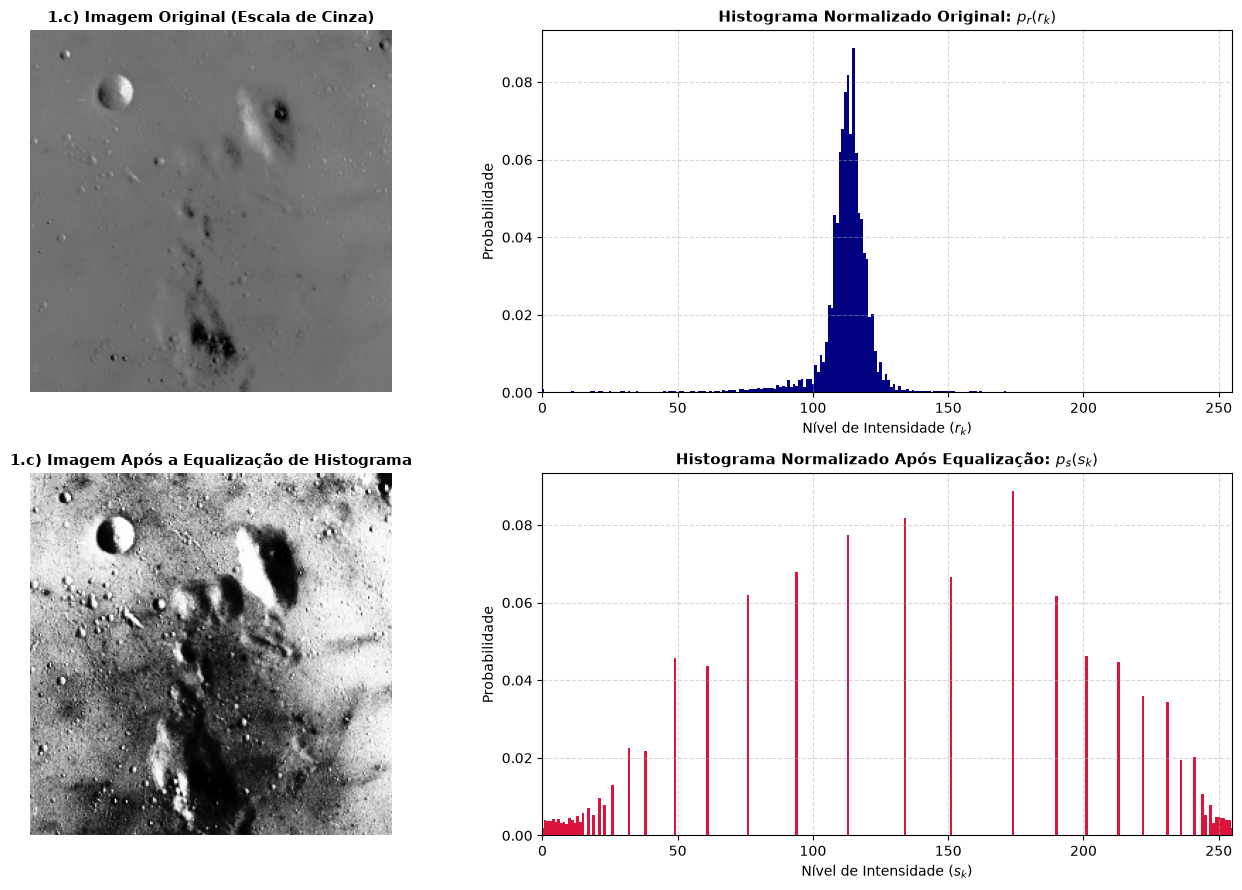

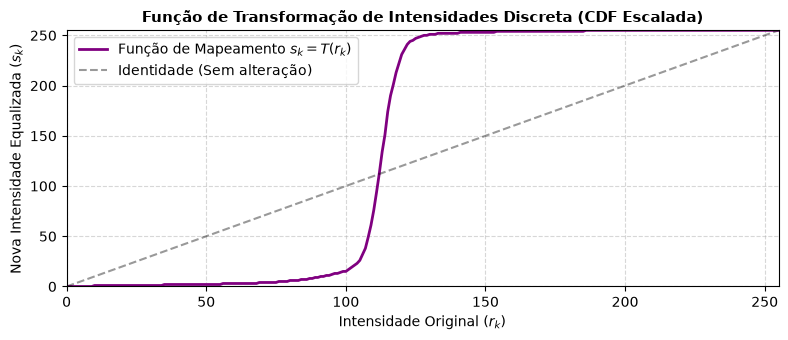

In [5]:
# Aplicação da equalização de histograma 100% manual
img_eq, s_k, pr_orig, cdf_orig = equalizar_histograma(img_q1)

# Histograma normalizado da imagem equalizada
hist_eq_abs = calcular_histograma(img_eq)
hist_eq_norm = normalizar_histograma(hist_eq_abs, total_pixels)

# Exibição comparativa 2x2 conforme solicitado na questão 1.c
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Linha 1: Imagem Original e seu Histograma Normalizado
axes[0, 0].imshow(img_q1, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("1.c) Imagem Original (Escala de Cinza)", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].bar(range(256), hist_norm, color='navy', width=1.0, edgecolor='none')
axes[0, 1].set_title("Histograma Normalizado Original: $p_r(r_k)$", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Nível de Intensidade ($r_k$)", fontsize=10)
axes[0, 1].set_ylabel("Probabilidade", fontsize=10)
axes[0, 1].set_xlim(0, 255)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# Linha 2: Imagem Equalizada e seu Histograma Normalizado
axes[1, 0].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("1.c) Imagem Após a Equalização de Histograma", fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].bar(range(256), hist_eq_norm, color='crimson', width=1.0, edgecolor='none')
axes[1, 1].set_title("Histograma Normalizado Após Equalização: $p_s(s_k)$", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Nível de Intensidade ($s_k$)", fontsize=10)
axes[1, 1].set_ylabel("Probabilidade", fontsize=10)
axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Gráfico da Função de Distribuição Acumulada (CDF) de transformação
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(256), s_k, color='purple', lw=2, label='Função de Mapeamento $s_k = T(r_k)$')
ax.plot([0, 255], [0, 255], 'k--', alpha=0.4, label='Identidade (Sem alteração)')
ax.set_title("Função de Transformação de Intensidades Discreta (CDF Escalada)", fontsize=11, fontweight='bold')
ax.set_xlabel("Intensidade Original ($r_k$)", fontsize=10)
ax.set_ylabel("Nova Intensidade Equalizada ($s_k$)", fontsize=10)
ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---
### Análise Adicional da Equalização com Segunda Imagem (`data.camera()`)
Para comprovar a robustez da implementação manual em diferentes distribuições de tons, aplicamos a equalização também sobre a imagem `data.camera()`.


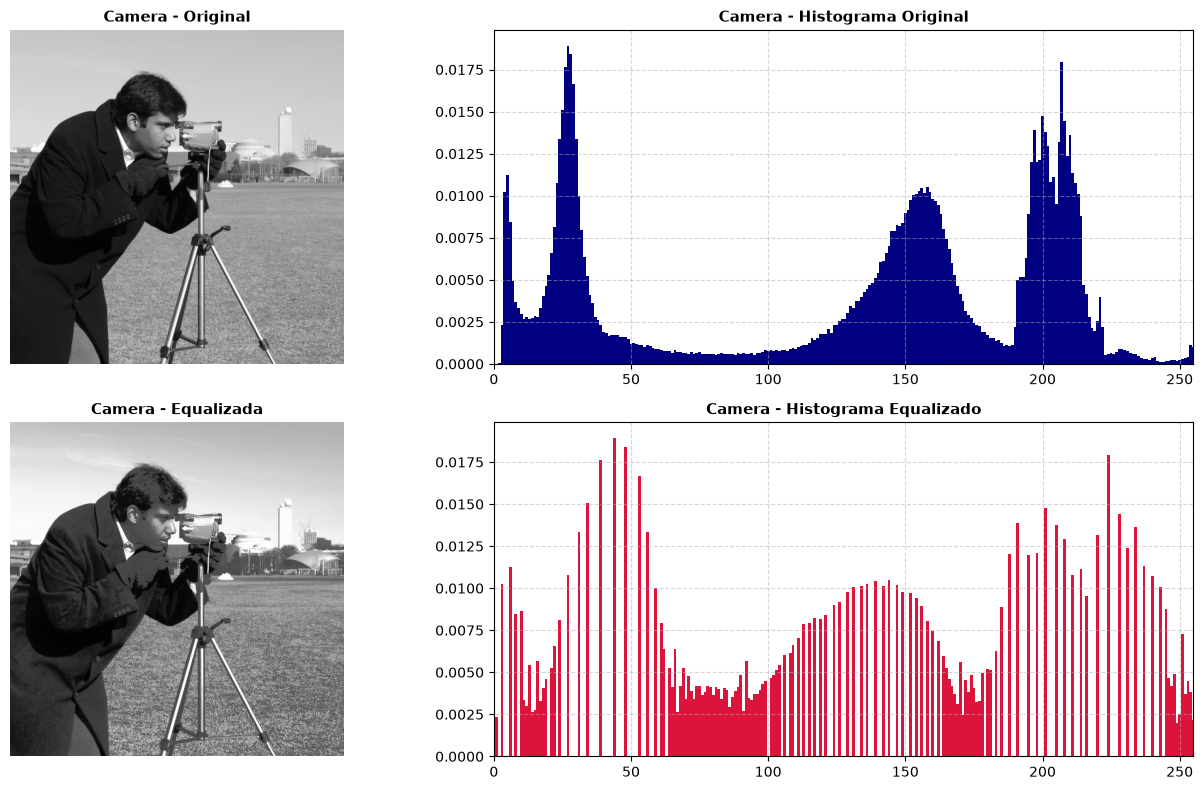

In [6]:
img_cam = data.camera()
M_cam, N_cam = img_cam.shape
tot_cam = M_cam * N_cam

# Equalização manual
img_cam_eq, s_cam, pr_cam_orig, _ = equalizar_histograma(img_cam)
pr_cam_eq = normalizar_histograma(calcular_histograma(img_cam_eq), tot_cam)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].imshow(img_cam, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Camera - Original", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].bar(range(256), pr_cam_orig, color='navy', width=1.0)
axes[0, 1].set_title("Camera - Histograma Original", fontsize=11, fontweight='bold')
axes[0, 1].set_xlim(0, 255)
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 0].imshow(img_cam_eq, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Camera - Equalizada", fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].bar(range(256), pr_cam_eq, color='crimson', width=1.0)
axes[1, 1].set_title("Camera - Histograma Equalizado", fontsize=11, fontweight='bold')
axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
## Questão 2) Especificação de Histograma (*Histogram Matching*)

Aplique a especificação do histograma utilizando a fórmula e mostre os seguintes itens:
* **a)** Mostre a imagem de entrada, juntamente com o gráfico do seu histograma normalizado antes da especificação.
* **b)** Mostre a imagem de referência, juntamente com o gráfico do seu histograma normalizado.
* **c)** Mostre a imagem de entrada, juntamente com o gráfico do seu histograma normalizado após a especificação.

---
### Metodologia da Especificação de Histograma
O processo transforma o histograma da imagem de entrada para corresponder à distribuição tonal de uma imagem de referência, seguindo as etapas ensinadas em aula:
1. Equalização da entrada: $s_k = T(r_k) = \text{round}\left((L-1) \sum_{j=0}^k p_r(r_j)\right)$
2. Equalização da referência: $v_q = G(z_q) = \text{round}\left((L-1) \sum_{i=0}^q p_z(z_i)\right)$
3. Mapeamento por proximidade: Para cada $s_k$, busca-se o $z_q$ que minimiza $|s_k - v_q|$.
4. Substituição direta: Cada pixel $r_k$ da imagem de entrada é substituído por seu $z_q$ mapeado.


In [7]:
# Definição das imagens para a especificação:
# Imagem de Entrada: Imagem de baixo contraste / escura (data.moon())
img_entrada = data.moon()

# Imagem de Referência: Imagem com distribuição tonal balanceada e ampla (data.camera())
img_referencia = data.camera()

# Executando a especificação de histograma 100% manual
img_especificada, mapa_transf, s_in, s_ref = especificar_histograma(img_entrada, img_referencia)

# Histogramas normalizados das três imagens
pr_entrada = normalizar_histograma(calcular_histograma(img_entrada), img_entrada.size)
pr_referencia = normalizar_histograma(calcular_histograma(img_referencia), img_referencia.size)
pr_especificada = normalizar_histograma(calcular_histograma(img_especificada), img_especificada.size)

print("Especificação de histograma concluída com sucesso!")
print(f"Dimensões Entrada:     {img_entrada.shape}")
print(f"Dimensões Referência:  {img_referencia.shape}")
print(f"Dimensões Especificada: {img_especificada.shape}")


Especificação de histograma concluída com sucesso!
Dimensões Entrada:     (512, 512)
Dimensões Referência:  (512, 512)
Dimensões Especificada: (512, 512)


---
### 2.a) Imagem de Entrada e seu Histograma Normalizado (Antes da Especificação)


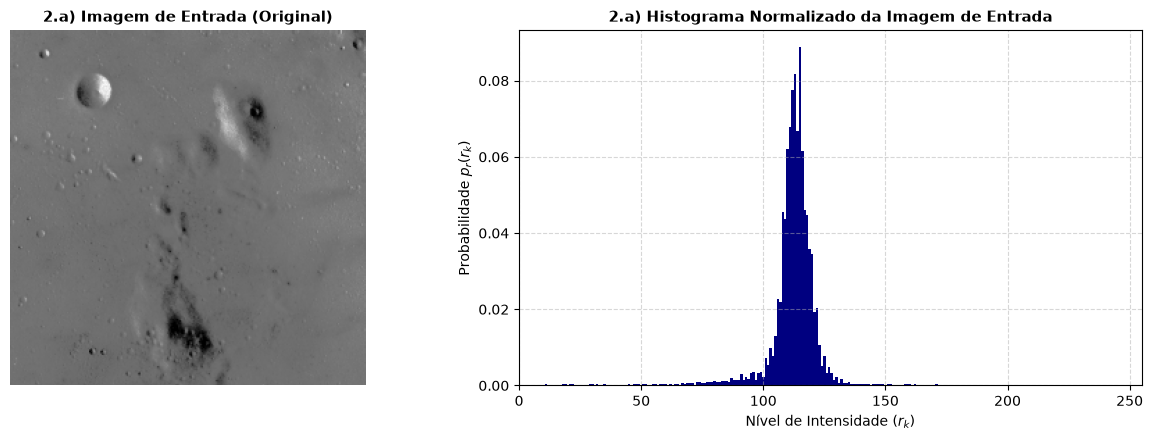

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].imshow(img_entrada, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("2.a) Imagem de Entrada (Original)", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].bar(range(256), pr_entrada, color='navy', width=1.0)
axes[1].set_title("2.a) Histograma Normalizado da Imagem de Entrada", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Nível de Intensidade ($r_k$)", fontsize=10)
axes[1].set_ylabel("Probabilidade $p_r(r_k)$", fontsize=10)
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
### 2.b) Imagem de Referência e seu Histograma Normalizado


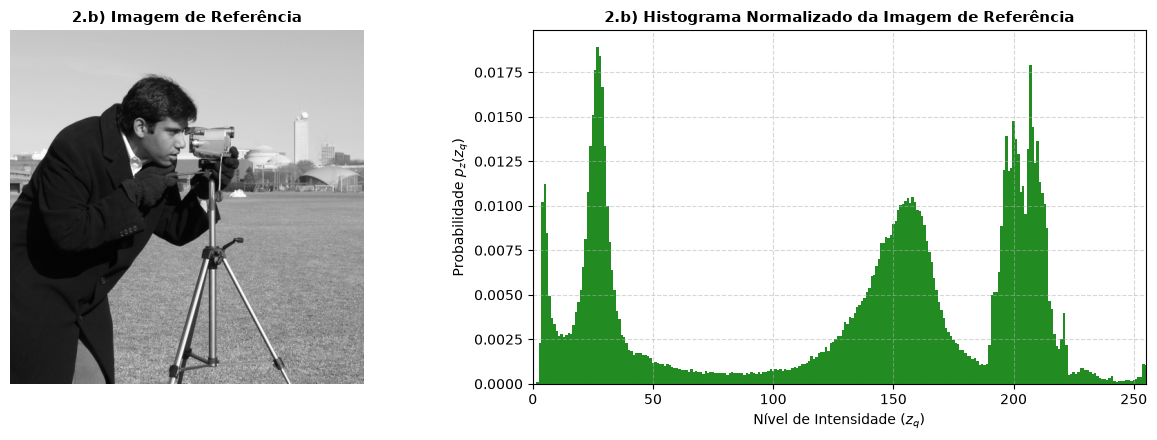

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].imshow(img_referencia, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("2.b) Imagem de Referência", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].bar(range(256), pr_referencia, color='forestgreen', width=1.0)
axes[1].set_title("2.b) Histograma Normalizado da Imagem de Referência", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Nível de Intensidade ($z_q$)", fontsize=10)
axes[1].set_ylabel("Probabilidade $p_z(z_q)$", fontsize=10)
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
### 2.c) Imagem de Entrada e seu Histograma Normalizado (Após a Especificação)


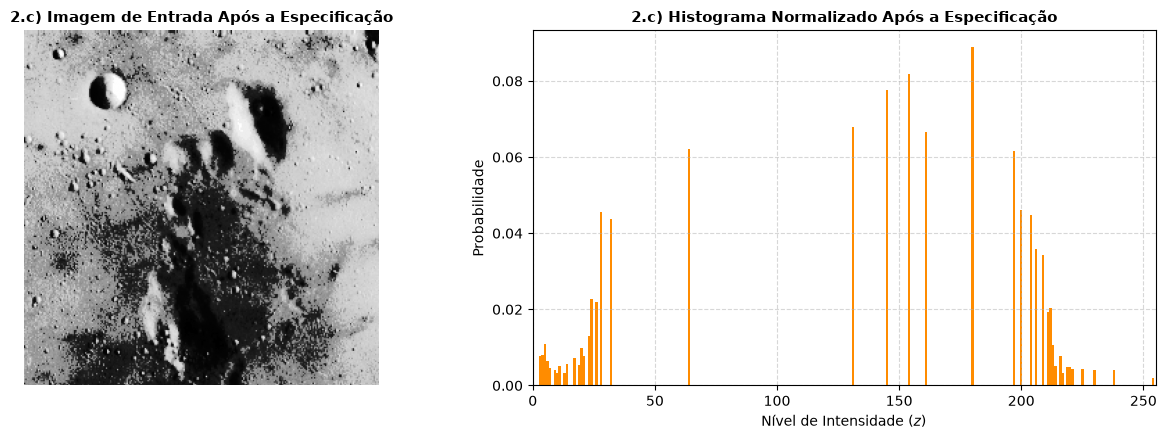

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].imshow(img_especificada, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("2.c) Imagem de Entrada Após a Especificação", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].bar(range(256), pr_especificada, color='darkorange', width=1.0)
axes[1].set_title("2.c) Histograma Normalizado Após a Especificação", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Nível de Intensidade ($z$)", fontsize=10)
axes[1].set_ylabel("Probabilidade", fontsize=10)
axes[1].set_xlim(0, 255)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
### Comparativo Unificado da Questão 2: Entrada vs. Referência vs. Especificada
O painel abaixo apresenta o conjunto completo das três etapas lado a lado para facilitar a comparação visual direta tanto das imagens quanto da transferência do perfil do histograma.


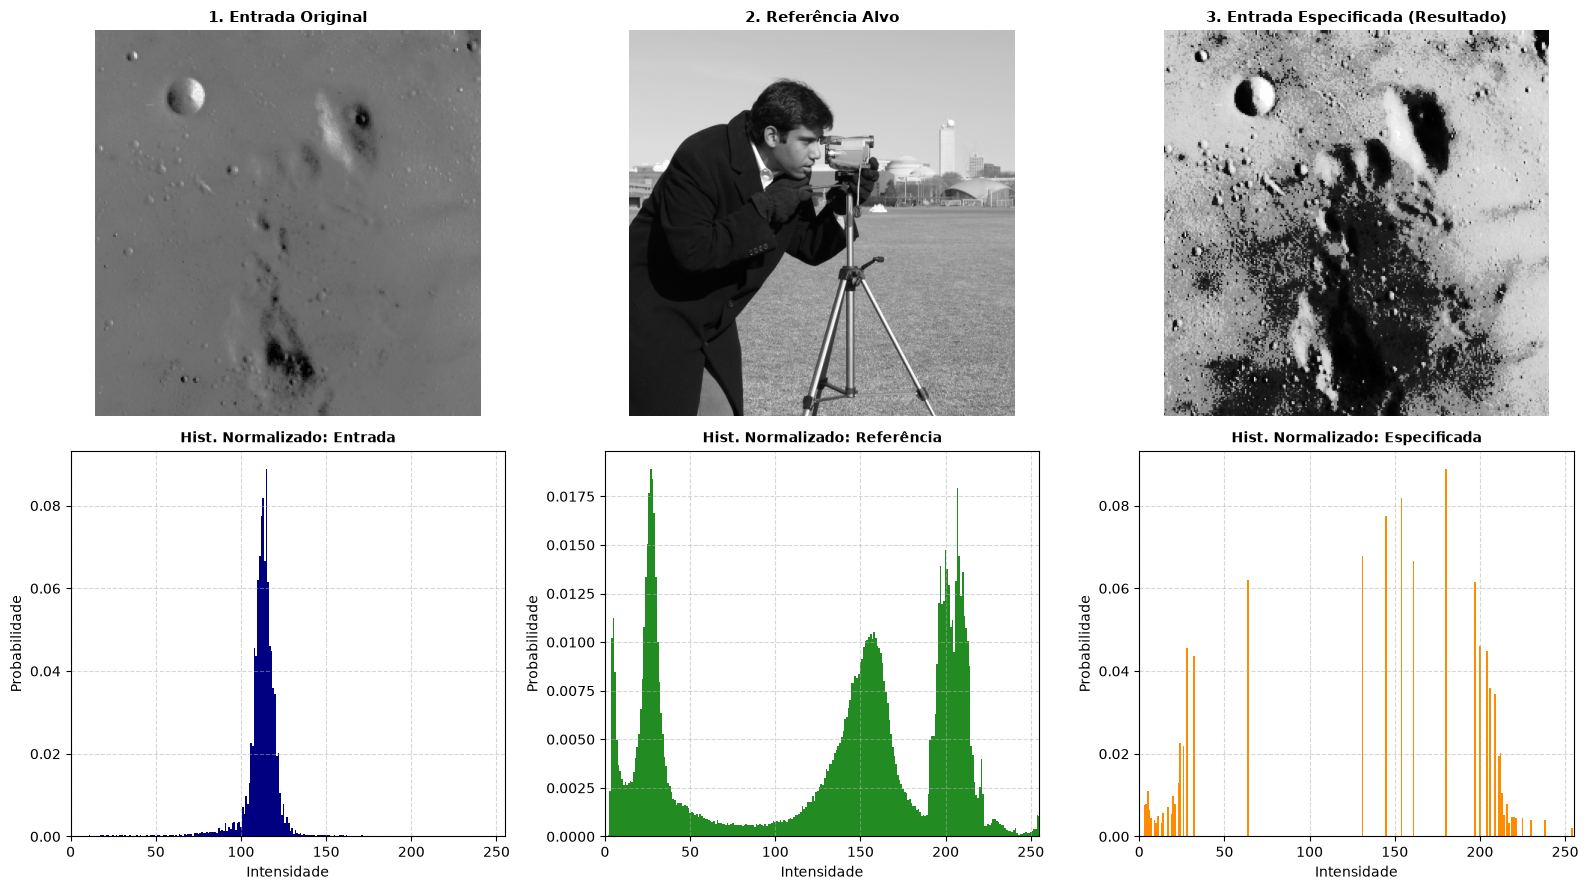

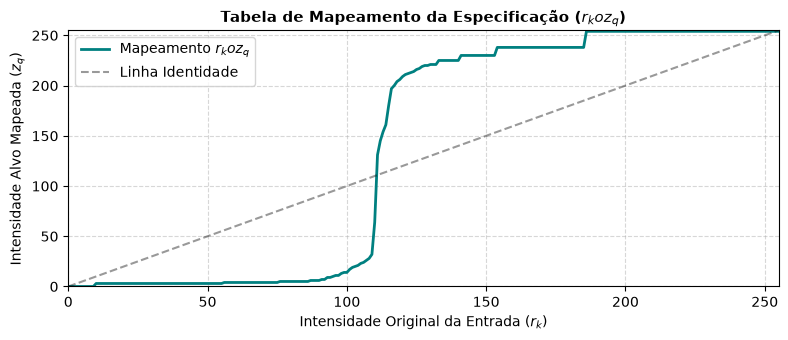

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Linha 1: Imagens
axes[0, 0].imshow(img_entrada, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("1. Entrada Original", fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_referencia, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("2. Referência Alvo", fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_especificada, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title("3. Entrada Especificada (Resultado)", fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

# Linha 2: Histogramas Normalizados
axes[1, 0].bar(range(256), pr_entrada, color='navy', width=1.0)
axes[1, 0].set_title("Hist. Normalizado: Entrada", fontsize=10, fontweight='bold')
axes[1, 0].set_xlabel("Intensidade")
axes[1, 0].set_ylabel("Probabilidade")
axes[1, 0].set_xlim(0, 255)
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].bar(range(256), pr_referencia, color='forestgreen', width=1.0)
axes[1, 1].set_title("Hist. Normalizado: Referência", fontsize=10, fontweight='bold')
axes[1, 1].set_xlabel("Intensidade")
axes[1, 1].set_ylabel("Probabilidade")
axes[1, 1].set_xlim(0, 255)
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 2].bar(range(256), pr_especificada, color='darkorange', width=1.0)
axes[1, 2].set_title("Hist. Normalizado: Especificada", fontsize=10, fontweight='bold')
axes[1, 2].set_xlabel("Intensidade")
axes[1, 2].set_ylabel("Probabilidade")
axes[1, 2].set_xlim(0, 255)
axes[1, 2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Curva da Tabela de Mapeamento HE(r_k) -> z_q
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(256), mapa_transf, color='teal', lw=2, label='Mapeamento $r_k \to z_q$')
ax.plot([0, 255], [0, 255], 'k--', alpha=0.4, label='Linha Identidade')
ax.set_title("Tabela de Mapeamento da Especificação ($r_k \to z_q$)", fontsize=11, fontweight='bold')
ax.set_xlabel("Intensidade Original da Entrada ($r_k$)", fontsize=10)
ax.set_ylabel("Intensidade Alvo Mapeada ($z_q$)", fontsize=10)
ax.set_xlim(0, 255)
ax.set_ylim(0, 255)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---
## Validação Numérica com Exemplo dos Slides de Aula ($L = 8, 64 \times 64$)

Para atestar a exatidão algorítmica da implementação manual, reproduzimos abaixo o exemplo numérico apresentado pelo professor na **Aula 05 (Slides 25 a 57)**:
* Imagem de entrada: $L = 8$ níveis de cinza, tamanho $64 \times 64 = 4096$ pixels com $n_k = [790, 1023, 850, 656, 329, 245, 122, 81]$.
* Imagem de referência com $HE(z_q) = [0, 0, 0, 1, 2, 5, 6, 7]$.
* Executamos o algoritmo e comparamos diretamente com os resultados dos slides 27 e 57.


In [12]:
# Dados dos slides da Aula 05
L = 8
MN = 4096
nk_aula = np.array([790, 1023, 850, 656, 329, 245, 122, 81])
pr_aula = nk_aula / MN

# Equalização manual da entrada
cdf_aula = np.cumsum(pr_aula)
s_aula = np.round((L - 1) * cdf_aula).astype(int)

# Níveis equalizados da referência (Slide 39)
he_ref_aula = np.array([0, 0, 0, 1, 2, 5, 6, 7])

# Tabela de mapeamento manual (distância mínima)
mapa_aula = np.zeros(L, dtype=int)
for rk in range(L):
    val_he = s_aula[rk]
    diffs = np.abs(he_ref_aula - val_he)
    mapa_aula[rk] = np.argmin(diffs)

# Exibição dos resultados em tabela formatada
print("=== TABELA DE VALIDAÇÃO COM O EXEMPLO DOS SLIDES ===")
print("rk  | nk   | pr(rk) | CDF   | s_calc | s_slide | HE(rk)->zq (calc) | Slide 57")
print("-" * 75)
s_slide_gabarito = [1, 3, 5, 6, 6, 7, 7, 7]
mapa_slide_gabarito = [3, 4, 5, 6, 6, 7, 7, 7]

for k in range(L):
    print(f"r{k} | {nk_aula[k]:4d} | {pr_aula[k]:.4f} | {cdf_aula[k]:.3f} |   {s_aula[k]}    |    {s_slide_gabarito[k]}    |       r{k} -> z{mapa_aula[k]}       |  r{k} -> z{mapa_slide_gabarito[k]}")

# Verificação formal
check_s = np.array_equal(s_aula, s_slide_gabarito)
check_map = np.array_equal(mapa_aula, mapa_slide_gabarito)
print("-" * 75)
print(f"Equalização idêntica aos slides:  {'APROVADO (100% EXATO)' if check_s else 'DIVERGENTE'}")
print(f"Mapeamento idêntico aos slides:   {'APROVADO (100% EXATO)' if check_map else 'DIVERGENTE'}")


=== TABELA DE VALIDAÇÃO COM O EXEMPLO DOS SLIDES ===
rk  | nk   | pr(rk) | CDF   | s_calc | s_slide | HE(rk)->zq (calc) | Slide 57
---------------------------------------------------------------------------
r0 |  790 | 0.1929 | 0.193 |   1    |    1    |       r0 -> z3       |  r0 -> z3
r1 | 1023 | 0.2498 | 0.443 |   3    |    3    |       r1 -> z4       |  r1 -> z4
r2 |  850 | 0.2075 | 0.650 |   5    |    5    |       r2 -> z5       |  r2 -> z5
r3 |  656 | 0.1602 | 0.810 |   6    |    6    |       r3 -> z6       |  r3 -> z6
r4 |  329 | 0.0803 | 0.891 |   6    |    6    |       r4 -> z6       |  r4 -> z6
r5 |  245 | 0.0598 | 0.950 |   7    |    7    |       r5 -> z7       |  r5 -> z7
r6 |  122 | 0.0298 | 0.980 |   7    |    7    |       r6 -> z7       |  r6 -> z7
r7 |   81 | 0.0198 | 1.000 |   7    |    7    |       r7 -> z7       |  r7 -> z7
---------------------------------------------------------------------------
Equalização idêntica aos slides:  APROVADO (100% EXATO)
Mapeamento id

---
## Conclusão da 5ª Atividade

1. **Cálculo e Normalização:** O histograma absoluto quantifica a distribuição empírica dos tons de cinza, enquanto a normalização converte as contagens em uma função de densidade de probabilidade discreta, invariante ao tamanho da imagem.
2. **Equalização:** Redistribui uniformemente a densidade acumulada das intensidades ao longo de todo o espectro $[0, 255]$, ampliando a faixa dinâmica e tornando evidentes detalhes antes imperceptíveis em áreas de baixo contraste.
3. **Especificação:** Demonstrou capacidade de transferir as características de iluminação e distribuição tonal da imagem de referência para a imagem de entrada, cumprindo com precisão a modelagem exigida em aplicações de visão computacional.
